In [3]:
# Import all Libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [4]:
df = pd.read_csv("df_clean.csv")

In [5]:
# Train-test split (80-20)
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)

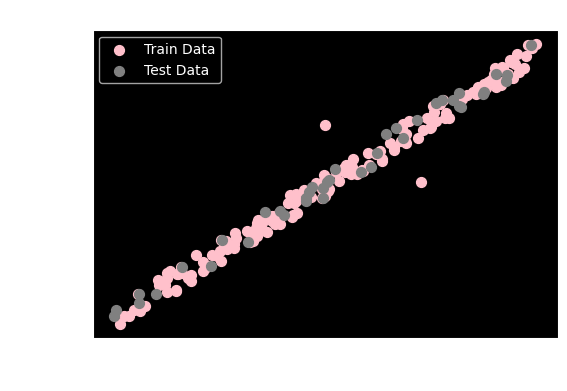

In [6]:
# Scatter plot with circular filled points, no grid

plt.figure(figsize=(6,4))
plt.style.use('dark_background')  # black background

plt.scatter(train_set['Size'], train_set['Price'], color='pink', label='Train Data', s=50, marker='o')
plt.scatter(test_set['Size'], test_set['Price'], color='grey', label='Test Data', s=50, marker='o')

plt.xlabel("Size (sqft)")
plt.ylabel("Price ($)")
plt.title("Train-Test Split Visualization")
plt.legend()
plt.grid(False)  # remove grid
plt.show()


<center><h1 style="color:darkblue;">Cross-Validation in Machine Learning</h1></center>

---

### 🔹 What is Cross-Validation?
Cross-validation tests how well a model will **generalize to unseen data**.  
Instead of training once and testing on a single hold-out set, the dataset is repeatedly split into train/test parts and results are averaged.

---

### 🔹 Why is it Required?
- A single train-test split (e.g., 80–20) may give **misleading results** if the split is “unlucky” (test set full of outliers).  
- Cross-validation reduces this risk by testing on **multiple splits**.  
- Helps detect:  
  - **Overfitting** → model memorizes training data.  
  - **Underfitting** → model too simple to capture patterns.  
- Provides a **robust estimate** of metrics like **$R^2$, RMSE**.  

---

### 🔹 Example: Simple Linear Regression (House Size → Price)
- **Single Split:**  
  Train model $Price = a + b \times Size$  on 80% of data, test on 20%.  
  Performance depends heavily on which houses fall in test set.  

- **K-Fold CV (k=5):**  
  - Split data into 5 folds.  
  - Train on 4 folds, test on 1 fold.  
  - Repeat 5 times so each fold serves as test set once.  
  - Average $R^2$ and RMSE across all folds.  

✔ Every data point is tested once → **fair, unbiased evaluation**.  

---

<center><h2 style="color:green;">Types of Cross-Validation</h2></center>

---

### 1️⃣ **Hold-Out Method (Train-Test Split)**
- **Process:** Split once into training (e.g., 80%) and testing (20%).  
- **Use Case:** Quick evaluation, but results vary by split.  
- **Linear Regression Example:** Train $Price = a + b \times Size$ on 80% of houses, test on remaining 20%.  

---

### 2️⃣ **K-Fold Cross-Validation**
- **Process:** Data split into *k* equal folds. Train on *k–1* folds, test on 1 fold, repeat *k* times.  
- **Advantage:** Every point used for both training and testing.  
- **Linear Regression Example:** With 5-fold, regression line fit 5 times, performance averaged.  

---

### 3️⃣ **Leave-One-Out CV (LOOCV)**
- **Process:** Special case of K-Fold where $k = n$ (number of samples).  
- **Advantage:** Maximum training data used each time.  
- **Drawback:** Very slow for large datasets.  
- **Linear Regression Example:** Each house left out once, model predicts its price, errors averaged.  

---

### 4️⃣ **Stratified K-Fold**
- **Process:** Like K-Fold but keeps **target distribution balanced** in each fold.  
- **Use Case:** Common in classification. For regression, variants like **Stratified Shuffle Split** are used.  
- **Linear Regression Example:** Less common, but ensures balanced house prices across folds if distribution is skewed.  

---

### 5️⃣ **Repeated K-Fold**
- **Process:** Perform K-Fold multiple times with different random splits.  
- **Advantage:** Reduces variability, more robust performance estimate.  
- **Linear Regression Example:** Useful when dataset is small and noisy.  

---

<center><h2 style="color:crimson;">👉 Summary</h2></center>

- **K-Fold CV** → Standard and practical choice.  
- **LOOCV** → Precise but very slow.  
- **Hold-Out** → Easy but unstable.  
- **Repeated K-Fold** → Most reliable for generalization estimate.  


### Overfitting Demo

### Cross Validation Demo

In [1]:
# ============================================
# Cross-Validation Demonstration for Linear Regression
# ============================================
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, make_scorer
from sklearn.model_selection import train_test_split, KFold, LeaveOneOut, RepeatedKFold, cross_val_score

In [7]:
# Features and target (Simple Linear Regression: Size -> Price)
X = df[['Size']]
y = df['Price']

In [8]:
# Model
model = LinearRegression()

# Custom scorers
r2_scorer = make_scorer(r2_score) #r2_scorer can be passed into cross_val_score

rmse_scorer = make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)))

#make_scorer converts any metric function into a scorer object that scikit-learn 
#can use in cross-validation.

results = {}

In [9]:
# ============================================
# 1. Hold-Out (Train-Test Split)
# ============================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
results['Hold-Out'] = {
    "R2": r2_score(y_test, y_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred))
}

In [10]:
# ============================================
# 2. K-Fold Cross Validation (k=5)
# ============================================
kf = KFold(n_splits=5, shuffle=True, random_state=42)
r2_scores = cross_val_score(model, X, y, cv=kf, scoring=r2_scorer)
rmse_scores = cross_val_score(model, X, y, cv=kf, scoring=rmse_scorer)
results['K-Fold (5)'] = {"R2": np.mean(r2_scores), "RMSE": np.mean(rmse_scores)}

In [15]:

# ============================================
# 3. Leave-One-Out Cross Validation (LOOCV)
# ============================================
loo = LeaveOneOut()
r2_scores = cross_val_score(model, X, y, cv=loo, scoring=r2_scorer)
rmse_scores = cross_val_score(model, X, y, cv=loo, scoring=rmse_scorer)
results['LOOCV'] = {"R2": np.mean(r2_scores), "RMSE": np.mean(rmse_scores)}

C:\Users\Milan\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:996: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
C:\Users\Milan\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:996: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
C:\Users\Milan\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:996: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
C:\Users\Milan\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:996: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
C:\Users\Milan\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:996: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn

C:\Users\Milan\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:996: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
C:\Users\Milan\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:996: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
C:\Users\Milan\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:996: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
C:\Users\Milan\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:996: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
C:\Users\Milan\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:996: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn

C:\Users\Milan\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:996: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
C:\Users\Milan\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:996: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
C:\Users\Milan\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:996: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
C:\Users\Milan\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:996: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
C:\Users\Milan\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:996: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn

C:\Users\Milan\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:996: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
C:\Users\Milan\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:996: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
C:\Users\Milan\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:996: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
C:\Users\Milan\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:996: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
C:\Users\Milan\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:996: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn

In [12]:
# ============================================
# 4. Repeated K-Fold (k=5, repeats=3)
# ============================================
rkf = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)
r2_scores = cross_val_score(model, X, y, cv=rkf, scoring=r2_scorer)
rmse_scores = cross_val_score(model, X, y, cv=rkf, scoring=rmse_scorer)
results['Repeated K-Fold (5x3)'] = {"R2": np.mean(r2_scores), "RMSE": np.mean(rmse_scores)}

In [16]:
# ============================================
# Print results
# ============================================
print("\n--- Cross-Validation Results ---")
for method, metrics in results.items():
    print(f"{method}: R² = {metrics['R2']:.4f}, RMSE = {metrics['RMSE']:.2f}")


--- Cross-Validation Results ---
Hold-Out: R² = 0.9892, RMSE = 12682.67
K-Fold (5): R² = 0.9833, RMSE = 15174.11
LOOCV: R² = nan, RMSE = 11400.35
Repeated K-Fold (5x3): R² = 0.9832, RMSE = 15166.82
